In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Transfer Learning and Fine Tuning Pretrained Models

Transfer learning is a way to reuse what a big CNN has already learned on one task (like ImageNet) and apply that knowledge to a new task (like cats vs dogs) so you get strong performance with less data, time, and compute.

### Intuition: Hierarchical Features

- In a CNN, **features are hierarchical** across layers.  
  - **Early layers** learn very simple patterns: edges, lines, corners, basic strokes.  
  - **Middle layers** learn combinations of these: textures, simple shapes, parts of objects (e.g., eye corners, wheel arcs).  
  - **Deeper layers** learn high-level concepts: whole faces, cars, animals, etc., depending on the training data.

- **Key observation:** those low‑level features (edges, lines, corners) are generic.  
  - Almost any natural image contains edges and simple shapes.  
  - **What changes from task to task is how those simple pieces are combined into higher‑level objects** (face vs car vs tumor).

- Core intuition of transfer learning:  
  `Features learned for one vision task (especially early/mid‑level) can be reused for many other vision tasks.`
  Examples:
  - Use features learned on a face dataset to help classify vehicles.  
  - Use features learned on natural images to detect anomalies in medical scans.  
  - Use the same backbone for cats vs dogs, cars vs trucks, or even some types of microscope images, despite the original model never seeing those exact images.

### Why transfer learning?

- **Less data required**  
  - Vanilla deep learning from scratch typically needs a large labeled dataset.  
  - With transfer learning, early layers already encode powerful features learned from millions of images.  
  - Your task can succeed even with a relatively small training set (sometimes thousands or even hundreds of examples).

- **Much faster training**  
  - Only the head (and maybe a few top layers, if you choose to fine‑tune) is trained.  
  - Fewer parameters → fewer gradient updates → shorter epochs and overall runtime.  
  - This allows experimentation on modest hardware and shorter iteration cycles in research or teaching.

- **State‑of‑the‑art or near‑state‑of‑the‑art performance with less effort**  
  - You stand on the shoulders of large ImageNet models that have already been optimized heavily.  
  - In practice, transfer learning often outperforms a from‑scratch model trained on the same small dataset.

- **Generalization across domains**  
  - Even when the target domain is not identical to ImageNet (e.g., medical or industrial images), low‑level visual primitives (edges, textures) are still relevant.  
  - With careful preprocessing and, if needed, some fine‑tuning on higher layers, transfer learning can still give strong results.

### ImageNet and Pretrained CNNs

[Imagenet](https://www.kaggle.com/discussions/getting-started/149448)

- ImageNet is a large‑scale image dataset:
  - Millions of labeled images.
  - Roughly 1000 object categories (dogs, cats, cars, trucks, tools, etc.).
  - Used for an annual competition (ImageNet Large Scale Visual Recognition Challenge).

- Because ImageNet is:
  - Huge (many images),
  - Diverse (many object classes and visual styles),  
  the CNNs trained on it learn very general, reusable visual features.

- Practical consequence:
  - We can take CNNs trained on ImageNet and apply them to:
    - Binary classification: cats vs dogs, cars vs trucks.
    - Fine‑grained tasks: specific dog breeds, different types of vehicles.
    - Related domains: some kinds of medical or microscope imagery, where edges/textures are still useful even if the exact objects are new.

- The depth of state-of-the-art neural networks has grown significantly over time—from AlexNet’s 8 layers to advanced ResNet models with up to 152 layers—enabled largely by advances in computational infrastructure.
- The availability of powerful multi-GPU distributed training systems made it feasible to train these very deep networks on massive datasets consisting of millions of images.
- Consequently, these pretrained networks have become excellent generic feature extractors, capturing rich representations applicable across many vision tasks.
- Today, such pretrained models serve as widely used commodity building blocks for deep learning practitioners worldwide, forming the backbone of many transfer learning and computer vision applications.


### Why Not Train ImageNet‑Scale CNNs?

- Training a large CNN on ImageNet from scratch is rarely feasible in a typical lab or classroom setting:
  - Historically: days, weeks, or even months of training.
  - Even today: still expensive; typically requires multi‑GPU or distributed setups.
  - Lots of engineering: hyperparameter tuning, learning rate schedules, regularization, etc.

- Fortunately:
  - Many top ImageNet models (e.g., VGG, ResNet, Inception, etc.) have publicly released pretrained weights.
  - Popular deep learning frameworks (such as TensorFlow/Keras and PyTorch) provide:
    - Built‑in model definitions (e.g., `keras_hub.ResNet50`).
    - Easy loading of ImageNet‑pretrained weights with a single flag or function call.
  - No need to train these large backbones.
  - Most low‑level hyperparameter search; the community has already done that.

### Architecture View: Body and Head

To explain transfer learning clearly, it helps to conceptually split a CNN into two parts.

- **Body (Feature Extractor / Feature Transformer)**  
  - Consists of convolutional + pooling layers.  
  - Takes raw pixels as input.  
  - Outputs a feature vector (or feature map) that encodes useful, high‑level information about the image.  
  - This is the part trained on ImageNet that learns edges → shapes → object parts → object‑level features.

- **Head (Task‑Specific Classifier / Regressor)**  
  - Consists of one or more fully connected (dense) layers.  
  - Takes the feature vector from the body as input.  
  - Outputs predictions specific to your task:
    - Binary classification (sigmoid output).
    - Multi‑class classification (softmax).
    - Regression (linear or other suitable output).

- Transfer learning workflow (conceptual):
  1. Start with a powerful CNN pretrained on ImageNet (full model: body + original head).
  2. “Chop off” the original head (the final classification layers trained to predict 1000 ImageNet classes).
  3. Keep the body as a generic feature extractor.
  4. Attach a new head designed for your task.

**Implementing the New Head**

- For a simple binary classification task (e.g., cars vs trucks, cats vs dogs):
  - Take the output of the CNN body (flatten or global pool it into a vector).
  - Add a single dense layer with:
    - 1 unit.
    - Sigmoid activation.
  - Interpret output as the probability of the positive class.

- For multi‑class classification (e.g., 10 dog breeds):
  - Take the body output.
  - Add:
    - Dense layer with $$K$$ units (where $$K$$ is the number of classes).
    - Softmax activation.

- For slightly more complex tasks:
  - Optionally insert additional dense layers (with ReLU, dropout, etc.) between the body’s output and the final classification layer.
  - This creates a small feed‑forward ANN on top of the frozen backbone.

### Transfer Learning Strategy: Freeze the Body

A fundamental and very common approach:

1. **Freeze the body**  
   - Do not update the weights of the convolutional layers.
   - In code, this usually means setting `trainable = False` for the backbone layers.
   - Intuition: the convolutional filters already encode very good generic features, thanks to ImageNet.

2. **Train only the head**  
   - Initialize the new head randomly.
   - Optimize only the head’s weights on your specific dataset.
   - No backpropagation into the backbone; gradients stop at the interface between body and head.

3. **Why this is fast and effective**:
   - You avoid updating millions of backbone parameters; you only train a relatively small number of parameters in the head.
   - Training converges quickly because:
     - The features coming from the body are already high‑quality.
     - The head is shallow and small.

4. **Interpretation**:
   - The convolutional body is a fixed “feature transformer” learned from a huge dataset.
   - Your small dataset only needs to learn “how to read” those features for your specific labels.

## Popular CNN Architectures


### **VGG16 & VGG19**

VGG is a popular deep convolutional neural network architecture developed by the Visual Geometry Group (VGG) that won the ImageNet challenge in 2014 for **both localization and classification tasks**.
- The VGG network is **notable for its simplicity** and uniform architecture using small 3x3 convolutional filters throughout, allowing it to effectively learn hierarchical features by stacking many layers.

#### VGG Architecture

- The core architecture consists of convolutional and pooling layers followed by fully connected layers, **much like the earlier LeNet network but deeper and more uniform**.  
- Key variants:
  - **VGG16:** 16 weighted layers — 13 convolutional layers plus 3 fully connected layers.  
  - **VGG19:** 19 weighted layers — 16 convolutional layers plus 3 fully connected layers.  
- **All convolutional layers use 3x3 kernels with stride 1 and padding 1 to preserve spatial resolution.**  
- Max-pooling layers are applied after certain convolution blocks to **reduce spatial dimensions and introduce translation invariance.**  
- ReLU activation is applied after every convolutional layer to introduce non-linearity.

- VGG’s success came from its ability to learn hierarchical visual features—edges and simple patterns in early layers, complex object parts and configurations in deeper layers.  
- It remains a foundational model for feature extraction in transfer learning due to its simplicity and widely available pretrained weights.

### **ResNet (Residual Network)**  




  - Known for residual connections (skip connections) allowing gradients to flow directly through identity branches.  
  - Variants include ResNet50, ResNet101, ResNet152, ResNet_v2, ResNeXt.  
  - Enables training of very deep networks without vanishing/exploding gradient issues.

### `Deeper is Better` — But With Limits

- In neural networks, **depth generally leads to increased expressiveness and better generalization**.  
- Intuition: more layers = more capacity to learn complex patterns.  
- However, empirically, **performance degrades beyond a certain depth.**  
- This is surprising and counterintuitive.

#### Why This Seems Wrong (Theoretical Argument)?

- Neural networks are **universal function approximators.**  
- They should easily learn the **identity function**: $f(x) = x$.  
- If we attach an identity network to an existing good network, the combined network logically should perform identically to the original.  
- By extension, we could stack many identity networks and never degrade performance.

**Conclusion:** Theoretically, deeper networks should perform at least as well as shallower networks.

###### The Practice-Theory Gap

- In practice, when training very deep networks end-to-end, performance **actually gets worse**.  
- Problem: training all weights simultaneously is difficult.  
- Gradients struggle to flow through many layers (vanishing gradient problem).  
- Optimizers get stuck in poor local minima.  
- Networks fail to learn even trivial identity mappings despite having the capacity.

### Residual Connection: Make Identity Learning Explicit

Instead of forcing a network to learn $f(x) = x$ implicitly, make it explicit:

- Create two parallel paths from input to output:
  1. **Main branch:** series of layers computing $F(x)$
  2. **Shortcut branch:** direct path (identity connection) passing $x$ unchanged

- **Final output:** $y = F(x) + x$ (addition before activation)

#### Why This Helps?

- The network no longer needs to learn identity from scratch.  
- Instead, the main branch only needs to learn the **residual**: the difference between desired output and identity.  
- Intuition: learning residuals (small perturbations) is much easier than learning the entire function.  
- If a layer decides to do nothing useful, it can simply learn $F(x) = 0$, yielding $y = 0 + x = x$ (identity).  
- If the layer wants to improve on identity, it has the freedom to do so.

### ResNet Architecture

#### Identity Block (First Type)

Used when input and output have the same spatial dimensions:

```
Input: X
   ↓
Conv → BatchNorm → ReLU
   ↓
Conv → BatchNorm → ReLU
   ↓
Conv → BatchNorm
   ↓
(+) Add X
   ↓
ReLU
   ↓
Output
```

**Key detail:** Final activation (ReLU) applies **after** the addition, not before.

#### Convolution Block (Second Type)

Used when input and output dimensions differ:

```
Input: X
   ↓
Main Branch:          Shortcut Branch:
Conv → BN → ReLU      Conv → BN
Conv → BN → ReLU        ↓
Conv → BN           (Different spatial dims)
   ↓                    ↓
   └─────---(+)─────────┘
        ↓
       ReLU
        ↓
     Output
```

The shortcut branch applies a convolution + batch norm to transform $X$ to match main branch output dimensions.

#### Handling Dimension Mismatches

When $F(x)$ and $x$ have different shapes:

- **Option 1:** Apply a learnable convolution matrix $W_s$ to $x$:
$$y = F(x) + W_s(x)$$  
- **Option 2:** Pad $x$ with zeros to match dimensions (no additional parameters).

### **Inception Networks**  


  - Uses parallel convolution filters of different sizes (1x1, 3x3, 5x5) in one module.  
  - Instead of picking a single filter size, it tries multiple simultaneously and concatenates results.  
  - Efficient in capturing multi-scale information.

### **MobileNet**


  - Designed for lightweight, fast inference on limited-resource devices (mobile, embedded).  
  - Trades off some accuracy for speed and smaller model size.

## Preprocessing for Pretrained CNNs



- When using pretrained CNNs, data must be preprocessed in the same way as the original training.  
- Common formats for pixel values:  
  - [1] or [-1, +1] normalized RGB values.  
  - VGG uses BGR format with pixel values centered but not scaled.  
- Each model typically offers a `preprocess_input` function (e.g., from TensorFlow/Keras applications) to handle this automatically.  
- Always apply the appropriate preprocessing function matching your chosen network.

### What is data Augumentation?

- Data augmentation creates virtual new data points to improve model generalization.  
- Python generators efficiently create augmented data on the fly without storage overhead.

#### Why Data Augmentation Matters

- For **tabular data**, you can only use the data you have; inventing new data risks adding biases.  
- For **image data**, you can create **new, valid data by applying transformations** like shifting, rotating, or flipping, since the semantic class remains unchanged.
- Augmentation helps make models more **robust and generalized** by simulating variations in training data.  
- Prevents **overfitting** by exposing the model to different transformed versions of the same data.    
- Storing all augmented data would require large storage and is inefficient.  
  - Instead, generate augmented images *on the fly* during training.

#### ImageDataGenerator for Loading and Augmentation

- Python/Keras provides `ImageDataGenerator` for:  
  - Loading images in batches from directories.  
  - Performing real-time data augmentation (flipping, rotating, shifting).  
  - Applying the correct preprocessing function per pretrained network.

- Use `flow_from_directory` method to:  
  - Automatically resize images to expected input size (e.g., 224x224).  
  - Create generators that yield batches indefinitely for training loops.

- Benefits: no need to manually manage file loading, batching, and augmentation.  
- Training calls use `model.fit_generator` or in newer APIs `model.fit` with generators.

### Folder Structure for ImageDataGenerator



- Organize data with this structure for automatic label inference:  
  - `train/` and `validation/` folders.  
  - Inside each, one folder per class (named by class label).  
  - Store actual image files inside the respective class folder.

Example:  
```
train/
   car/
     car001.jpg
     car002.jpg
   truck/
     truck001.jpg
     truck002.jpg
validation/
   car/
   truck/
```

- This structure enables `flow_from_directory` to map images to labels automatically based on folder names.

### DataGenerators and Image Augumentation

- Small datasets loaded via Keras API fit comfortably in memory for straightforward use.  
- Real-world datasets can be very large, exceeding memory limits.  
- Generators help by yielding data batches on the fly, so the entire dataset doesn’t need to be loaded at once.


#### What is a Python Generator?

- A **generator** is a Python function that yields items one at a time.

- Generators are functions that use `yield` instead of `return`.
- This allows processing large datasets or data streams efficiently without loading all data at once.   
- They produce a sequence of values lazily, maintaining their internal state between calls without holding all data in memory.  
- Ideal for streaming large datasets or performing complex preprocessing on the fly.

Simple data generator using python

In [ ]:
import numpy as np

In [ ]:
def my_random_generator():
    for _ in range(10):
        x = np.random.randn()
        yield x

In [ ]:
my_random_generator()

<generator object my_random_generator at 0x7ef8386df370>

In [ ]:
next(my_random_generator())

-0.6942895490405604

In [ ]:
for x in my_random_generator():
    print(x)

0.8601900602418067
0.23142360191995193
-0.05890033773036302
-0.10205577339732785
-1.2857144989218763
0.8737563684848195
-0.30213552314212905
1.0569685087337366
-0.9635742068153582
-0.5734027607099365


### Applying Generators for Data Augmentation

- Conceptually, for image batches. Each batch is augmented differently as the generator is iterated over during training.

````
def my_image_augmentation_generator(x_train, y_train):
    for x_batch, y_batch in zip(x_train, y_train):
        x_batch_augmented = augment(x_batch)  # Apply random transformations
        yield x_batch_augmented, y_batch
````

### Keras `ImageDataGenerator`

- Keras’s `ImageDataGenerator` provides easy-to-use interfaces for a wide range of standard augmentations.  
- Normalization and custom functions extend the power of the augmentation pipeline.  
- Integrating augmentation into training pipelines leads to better performance on unseen data.
- The generator applies random transformations specified in the constructor to the image.  
- Each batch produced contains augmented versions, useful for creating varied training data on the fly.
- Keras simplifies augmentation with `ImageDataGenerator`:  

```python
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_generator = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = data_generator.flow(x_train, y_train, batch_size=32)
```

- Supports numerous augmentations: rotation, shifts, flips, brightness, shear, zoom.  
- Use `.flow()` to generate batches of augmented images during training.

### Advanced Augmentation: Normalization

- Keras supports **feature-wise** and **sample-wise** normalization as augmentation techniques.

```python
datagen_norm = ImageDataGenerator(
    featurewise_center=True,          # Subtract mean across dataset
    featurewise_std_normalization=True,  # Divide by std dev across dataset
    samplewise_center=True,           # Subtract mean from each sample
    samplewise_std_normalization=True # Divide each sample by its std dev
)

# Compute mean and std on training images
datagen_norm.fit(training_images)

# Create generator for normalized images
train_gen_norm = datagen_norm.flow(training_images, batch_size=32)
```

- **Feature-wise** operations compute and apply statistics across the full dataset.  
- **Sample-wise** operations normalize each individual image separately.

### Custom Augmentation Functions

- You can define any function to apply custom augmentations.

```python
import numpy as np
# Define a function to add random noise to images
def add_random_noise(img):
    noise = np.random.normal(loc=0, scale=25, size=img.shape)
    img_noisy = img + noise
    img_noisy = np.clip(img_noisy, 0, 255)  # Clip to valid range
    return img_noisy

# Use custom function in ImageDataGenerator
datagen_custom = ImageDataGenerator(preprocessing_function=add_random_noise)

# Apply on training images
train_gen_custom = datagen_custom.flow(training_images, batch_size=32)
```

- Custom functions allow complete control over augmentation beyond built-in parameters.

### Training with Generators in Keras



- Because a generator can loop infinitely, specify `steps_per_epoch`:  

```python
steps_per_epoch = len(x_train) // 32  # batches per epoch

history = model.fit_generator(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=50
)
```

- `fit_generator` internally calls the generator until it reaches `steps_per_epoch` batches per epoch.  
- Returns a training history object recording metrics like loss, which can be plotted:  

## Greedy Layer-Wise Pre-Training

Greedy layer-wise pre-training is an approach **originally developed to train deep neural networks more effectively by breaking down the training process into manageable steps**, which is especially useful when training very deep networks was difficult.

### Why Greedy Layer-Wise Pre-Training?



- It simplifies optimization by training one shallow layer at a time instead of the full deep network at once.  
- The layer-wise unsupervised training preserves important features in earlier layers and provides a good initialization for supervised training.  
- Helps **combat problems like vanishing gradients and poor local minima in deep networks**.  
- The method represents an early form of unsupervised deep learning, showing how pretraining layers using reconstruction losses can bootstrap feature learning.  
- Most modern transfer learning approaches build on similar foundational ideas but with improved training techniques and architectures.


### Greedy Layer-Wise Pre-Training Steps

1. **Step 1: Train First Autoencoder**  
   - Train a shallow autoencoder on the original images $X$ to reconstruct them as closely as possible, producing reconstructions $X'$.  
   - Keep only the encoder half (first half) of this autoencoder; discard the decoder half.

2. **Step 2: Train Subsequent Autoencoders on Encoded Data**  
   - Transform the dataset using the first encoder to get $Z = f(X)$.  
   - Train a second autoencoder to reconstruct $Z$ itself, producing $Z'$.  
   - Again, keep only the encoder half of this second autoencoder and discard the decoder half.

3. **Step 3: Stack Encoders to Build Deep Network**  
   - Attach the first half of the second autoencoder to the first half of the first autoencoder, effectively stacking pretrained layers.  
   - Repeat the process as desired to build a deep stack of pretrained encoder layers.

4. **Step 4: Add Logistic Regression Output Layer**  
   - Attach a logistic regression (or other supervised output layer) on top.  
   - Train options:  
     - Train only the logistic regression layer (freeze pretrained layers).  
     - Fine-tune the entire deep network end-to-end.  
     - Or, train the top layer first, then fine-tune later.

- The pretrained stacked encoders are similar in spirit to large pretrained CNN backbones used in transfer learning.  
- Training the logistic regression layer on top parallels adding a task-specific head in transfer learning.  
- Fine-tuning strategies echo current approaches where pretrained weights are adapted to new tasks.

## Two approches to Transfer Learning: Image Augumentation

There are two main practical approaches to implementing transfer learning when using large pretrained CNNs with a smaller new classification head, especially when the body network is very deep

#### Approach #1: With Data Augmentation

Full CNN Computation Inside Training Loop

- Each batch of input images $x$ is passed through the full pretrained CNN body (feature extractor) every training iteration to compute feature vectors $z = f(x)$.  
- The small head (e.g., logistic regression layer) uses these $z$ to predict outputs $\hat{y}$.  
- The **head's weights are updated using gradient descent** for each batch based on the prediction errors.  
- **Data augmentation is applied during training**, so input images $x$ vary slightly each epoch, resulting in different $z$ each time.  
- **Pros:**  
  - Allows use of data augmentation, which typically improves model generalization.  
- **Cons:**  
  - Computation is slower because the expensive CNN body is run for every batch and epoch.

- The CNN is split conceptually into:  
  - Body: $z = f(x)$ (feature extractor, expensive to compute)  
  - Head: $\hat{y} = \mathrm{softmax}(W z + b)$ or logistic regression layer (fast)  

In full training loop approach, compute $z$ fresh for each batch:  
  ```python
  for epoch in epochs:
      shuffle(batches)
      for x, y in batches:
          z = cnn_body(x)  # compute features each batch
          y_hat = softmax(np.dot(z, W) + b)
          grad_w, grad_b = gradient(error(y, y_hat))
          update(W, b, grad_w, grad_b)
  ```

#### Approach #2: Precompute Features (No Data Augmentation)

- Before training, pass all raw input images $X$ through the pretrained CNN body once to get fixed feature vectors $Z = f(X)$.  
- Use these fixed $Z$ and labels $Y$ to train a logistic regression or small dense head.  
- Training only involves the **lightweight classifier without repeatedly running the CNN body.**  
- **Pros:**  
  - Much faster training since the CNN feature extraction is done once and not repeated.  
- **Cons:**  
  - Cannot use data augmentation since $Z$ is fixed and no longer varies with modified inputs.  
  - Possibly worse generalization without augmentation support.

- In precompute approach, compute all features once before training:  
  ```python
  Z = cnn_body(X)  # precompute once for entire dataset
  # Then train classifier only on (Z,Y):
  train_logistic_regression(Z, Y)
  ```



| Aspect            | With Data Augmentation (Full CNN per batch) | Without Data Augmentation (Precompute Features) |
|-------------------|---------------------------------------------|------------------------------------------------|
| Computation Speed | Slow (CNN run every batch)                   | Fast (CNN run once upfront)                     |
| Accuracy/Generalization | Better - augmentation aids robustness      | Possibly worse - no augmentation                |
| Implementation Complexity | Higher - needs generator and batch-wise CNN computation | Lower - treat as tabular problem                  |

- Use Approach #1 for the best model quality if computational resources/time allow and you want to leverage augmentation.  
- Use Approach #2 for faster experiments or when compute is limited, accepting some potential loss in accuracy.  
- It's valuable to try both to see which strikes the best trade-off for your problem.

## Pretrained Classifier

In [ ]:
try:
  import keras_hub
  import keras_core as keras
except:
  !pip install keras_hub
  import keras_hub

In [ ]:
import json
import numpy as np
import keras

Load an Image

In [ ]:
dog_img = keras.utils.load_img('/content/dog.29.jpg')
cat_img = keras.utils.load_img('/content/cat_or_dog_2.jpg')

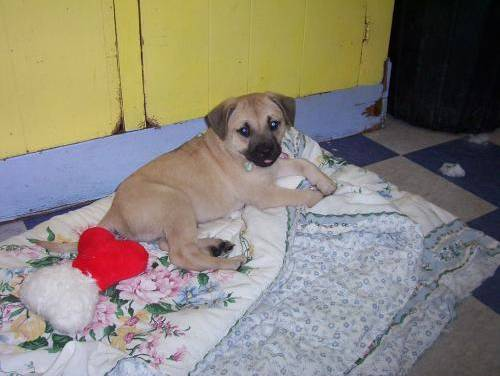

In [ ]:
dog_img

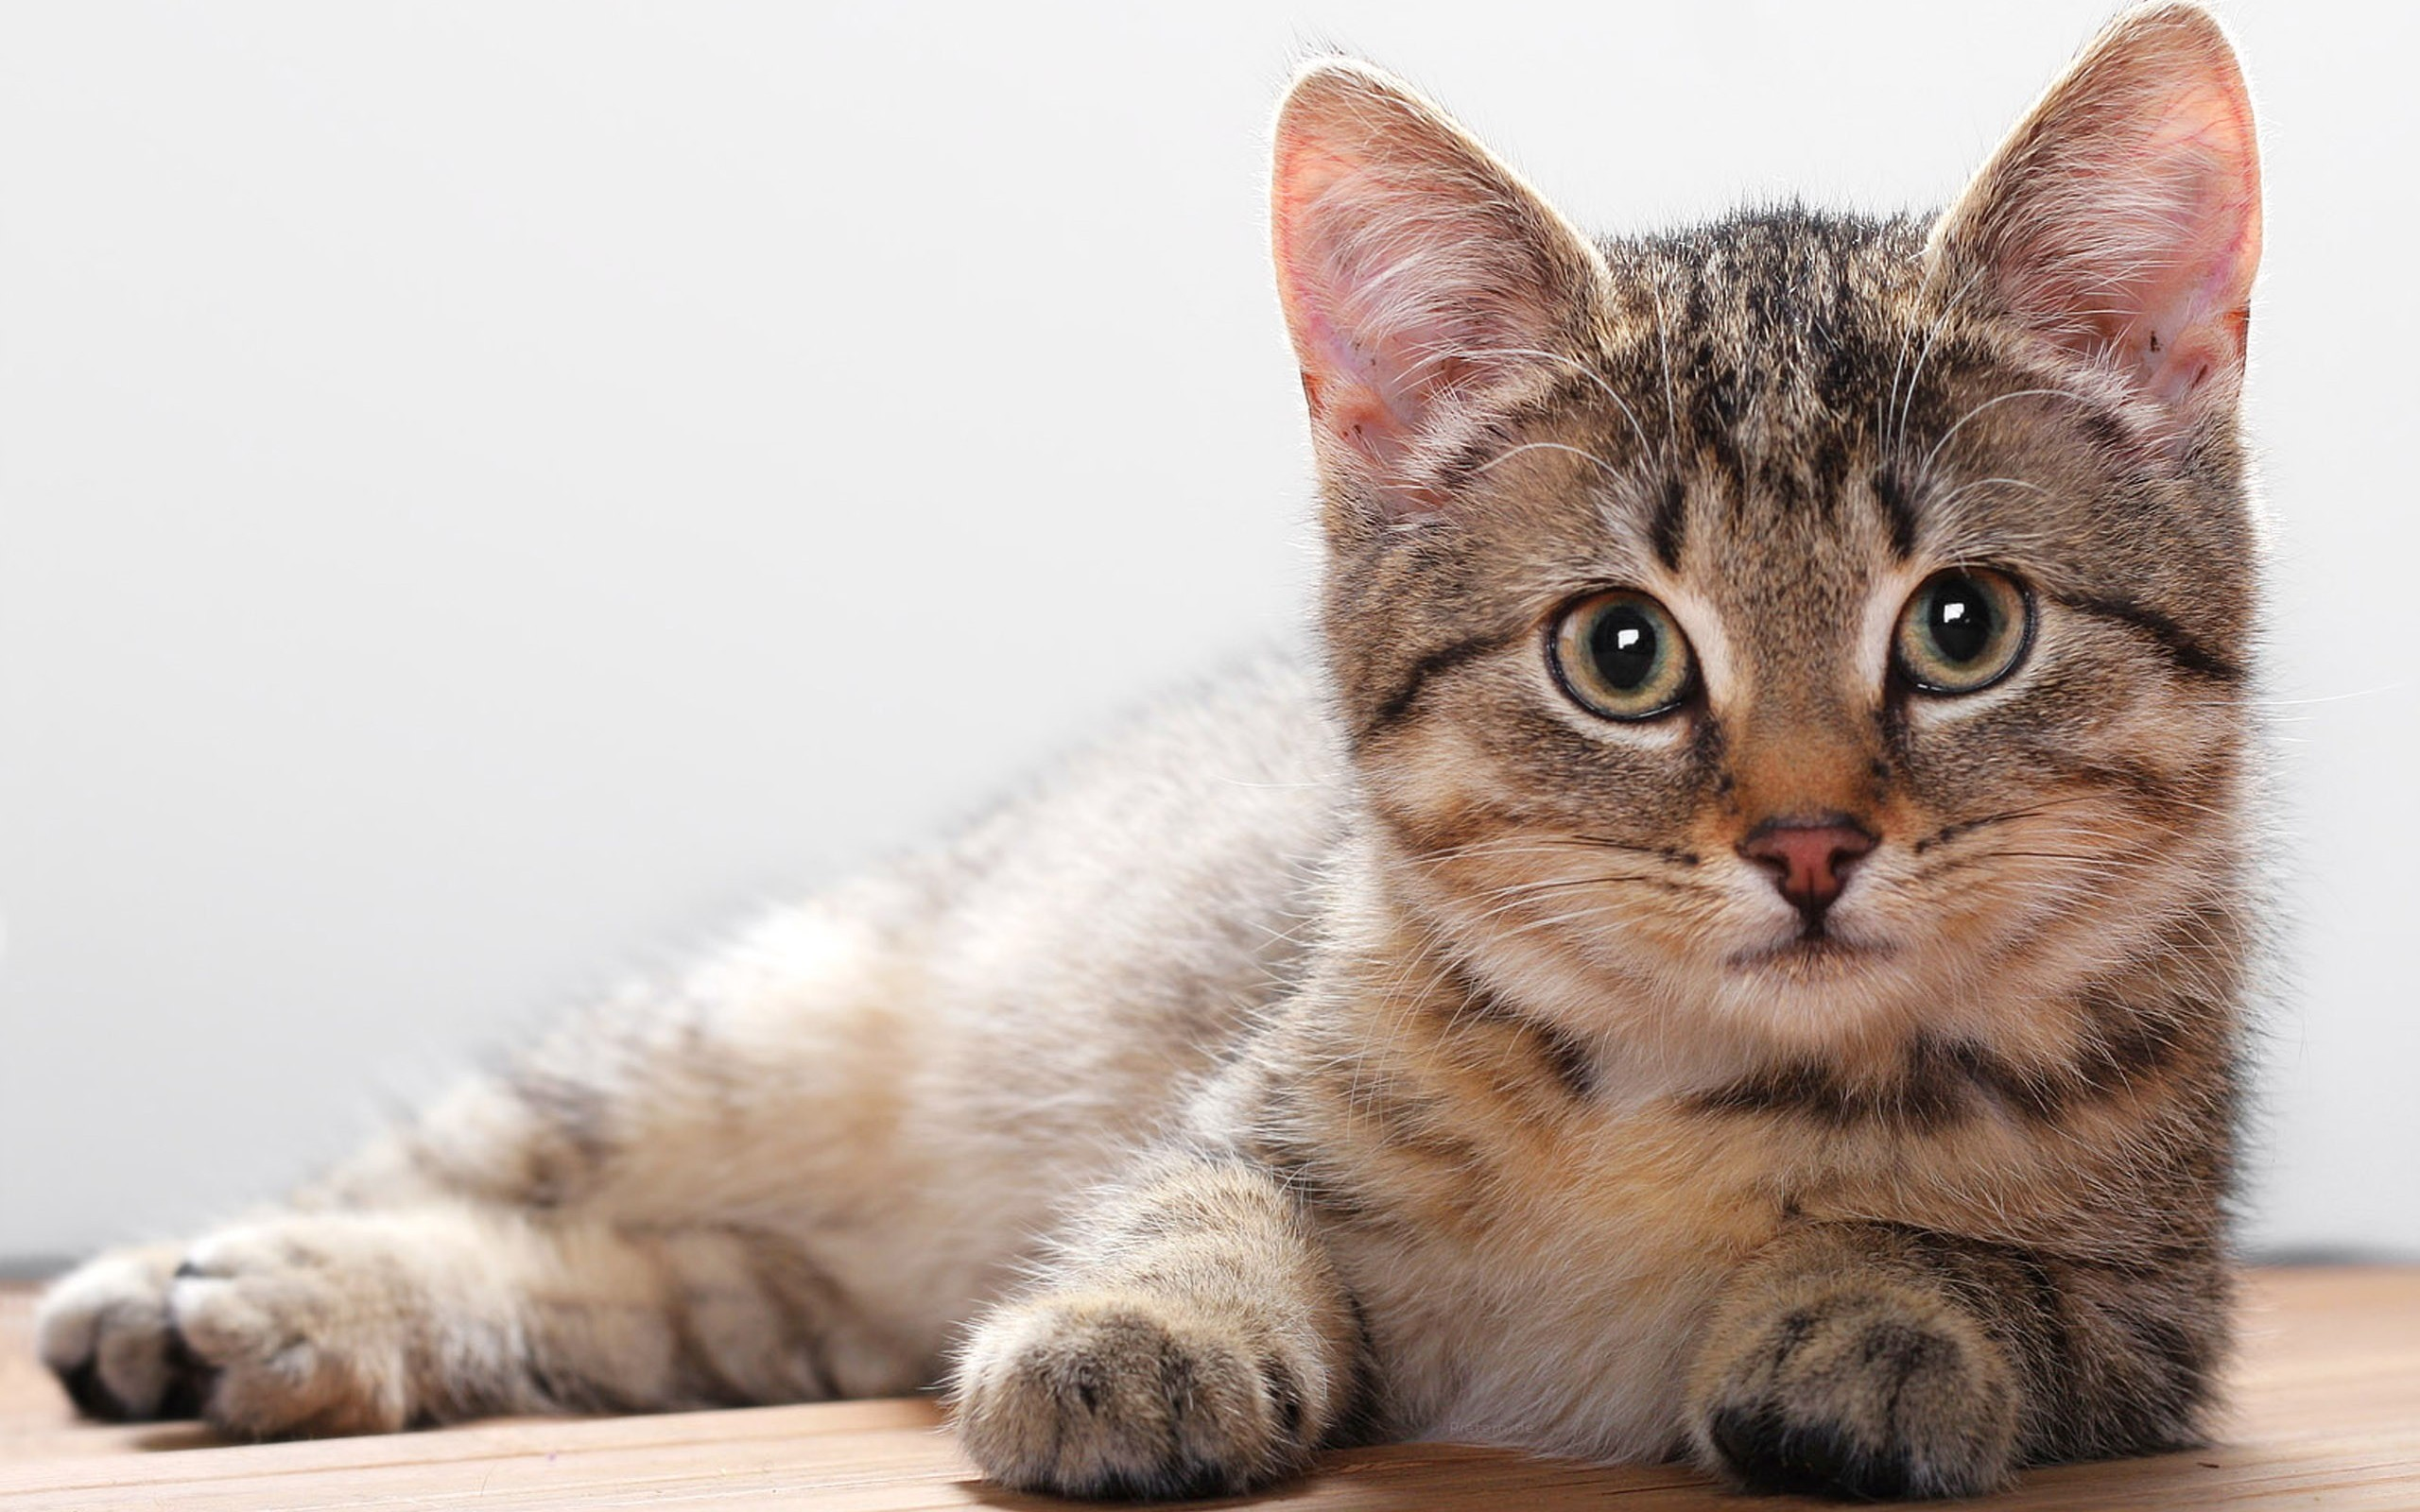

In [ ]:
cat_img

In [ ]:
dog_arr = np.array(dog_img)
dog_arr.shape

(376, 500, 3)

In [ ]:
cat_arr = np.array(cat_img)
cat_arr.shape

(1600, 2560, 3)

Import pretrained model

In [ ]:
# Load the pretrained ResNet50 ImageNet model
model = keras_hub.models.ImageClassifier.from_preset('resnet_50_imagenet')

# Display model architecture summary
model.summary()

Preprocessor: "res_net_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ res_net_image_converter (ResNetImageConverter)                │                   Image size: (224, 224) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "res_net_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)                      │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ res_net_backbone (ResNetBackbone)             │ (None, None, None, 2048)           │          23,561,152 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ pooler (GlobalAveragePooling2D)               │ (None, 2048)                       │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ output_dropout (Dropout)                      │ (None, 2048)                       │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                           │ (None, 1000)                       │           2,049,000 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 25,610,152 (97.69 MB)

 Trainable params: 25,557,032 (97.49 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
image_batch = dog_arr.reshape(-1, 376, 500, 3)
image_batch.shape

(1, 376, 500, 3)

In [ ]:
probs = model.predict(image_batch)
probs.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step


(1, 1000)

In [ ]:
from keras.applications.imagenet_utils import decode_predictions
# Decode the top 5 predicted classes per image
decoded_preds = decode_predictions(probs, top=5)

for pred in decoded_preds:
    for _, class_name, score in pred:
        print(f"{class_name}: {score:.4f}")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Border_terrier: -1.4719
Staffordshire_bullterrier: -1.5812
bull_mastiff: -1.5826
pug: -2.4807
American_Staffordshire_terrier: -2.8385


In [ ]:
from keras.applications.imagenet_utils import decode_predictions

def get_imagenet_predictions(model, image_path):
    # Load and resize the image
    img = keras.utils.load_img(image_path, target_size=(224, 224))

    # Convert image to array
    img_arr = np.array(img)

    # Add batch dimension
    image_batch = np.expand_dims(img_arr, axis=0)

    # # Preprocess input according to model's requirements
    preprocessed = keras.applications.resnet.preprocess_input(image_batch.astype(np.float32))

    # Predict probabilities
    probs = model.predict(preprocessed)
    # probs = model.predict(image_batch)

    # Decode top 5 predictions
    decoded_preds = decode_predictions(probs, top=5)

    # Print predictions
    for pred in decoded_preds:
        for _, class_name, score in pred:
            print(f"{class_name}: {score:.4f}")


In [ ]:
image_path = '/content/cat_or_dog_2.jpg'
get_imagenet_predictions(model, image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
tabby: 0.8513
Egyptian_cat: -0.2367
tiger_cat: -0.5489
lynx: -4.6528
kit_fox: -5.7589


## Finetune a Pretrained Classifier

In [ ]:
import numpy as np
import keras, keras_hub
import tensorflow as tf

In [ ]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
!nvidia-smi

Sun Nov 16 00:50:33 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             11W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Import dataset

In [ ]:
!wget -nc https://archive.org/download/lions_cheetahs/lions_cheetahs.zip

--2025-11-16 00:50:33--  https://archive.org/download/lions_cheetahs/lions_cheetahs.zip
Resolving archive.org (archive.org)... 207.241.224.2
Connecting to archive.org (archive.org)|207.241.224.2|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://dn721905.ca.archive.org/0/items/lions_cheetahs/lions_cheetahs.zip [following]
--2025-11-16 00:50:34--  https://dn721905.ca.archive.org/0/items/lions_cheetahs/lions_cheetahs.zip
Resolving dn721905.ca.archive.org (dn721905.ca.archive.org)... 204.62.247.77
Connecting to dn721905.ca.archive.org (dn721905.ca.archive.org)|204.62.247.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 74771166 (71M) [application/zip]
Saving to: ‘lions_cheetahs.zip’

lions_cheetahs.zip  100%[===================>]  71.31M  15.2MB/s    in 5.7s    

2025-11-16 00:50:41 (12.5 MB/s) - ‘lions_cheetahs.zip’ saved [74771166/74771166]



In [ ]:
!unzip '/content/lions_cheetahs.zip'

Archive:  /content/lions_cheetahs.zip
  inflating: images/Cheetahs/0052cb267268c59e.jpg  
  inflating: images/Cheetahs/00707659aba29334.jpg  
  inflating: images/Cheetahs/007f9ffc01c7b106.jpg  
  inflating: images/Cheetahs/00bb45a8568a3474.jpg  
  inflating: images/Cheetahs/00c8d36882dd6d37.jpg  
  inflating: images/Cheetahs/00d100b0231b60e6.jpg  
  inflating: images/Cheetahs/00d9eb862ba3dfc6.jpg  
  inflating: images/Cheetahs/012f5ecbf49e1da0.jpg  
  inflating: images/Cheetahs/01750ba1a197e3ad.jpg  
  inflating: images/Cheetahs/01d688c043bdbfbb.jpg  
  inflating: images/Cheetahs/0230496e4a8ed917.jpg  
  inflating: images/Cheetahs/02871f24d5abe59c.jpg  
  inflating: images/Cheetahs/029b39c0b65ebeb3.jpg  
  inflating: images/Cheetahs/02a0439923768403.jpg  
  inflating: images/Cheetahs/02a5846a35629f1d.jpg  
  inflating: images/Cheetahs/02b086c4e96396f6.jpg  
  inflating: images/Cheetahs/02dd8dd4344b04a7.jpg  
  inflating: images/Cheetahs/0321448f2848ab99.jpg  
  inflating: images/Cheeta

In [ ]:
!ls

images	lions_cheetahs.zip  sample_data


In [ ]:
!ls images

Cheetahs  Lions


In [ ]:
!ls images/Cheetahs/

0052cb267268c59e.jpg  0c20fa69621a2e6c.jpg  4d5ff3bad0444108.jpg
00707659aba29334.jpg  0c61b8d86a3e0889.jpg  519587ae1f0b5160.jpg
007f9ffc01c7b106.jpg  0c6e90e19f2b2bbc.jpg  5233078010f25f0c.jpg
00bb45a8568a3474.jpg  0db6601682a368e8.jpg  52b64d96fc0647e8.jpg
00c8d36882dd6d37.jpg  0fb021bac7207533.jpg  601c4f42bfb9c50d.jpg
00d100b0231b60e6.jpg  11377ee99115ffff.jpg  6795bb2c553f4981.jpg
00d9eb862ba3dfc6.jpg  113fbf2203ccef57.jpg  6d613ea1b58411f1.jpg
012f5ecbf49e1da0.jpg  1140e3015190cfeb.jpg  75ea322880cfcc3a.jpg
01750ba1a197e3ad.jpg  11c270e6589dce6e.jpg  767e3c2968ff1890.jpg
01d688c043bdbfbb.jpg  12271a9ed07dc28e.jpg  775f869903916081.jpg
0230496e4a8ed917.jpg  135b67b72eb7bb47.jpg  784940fed90cccc2.jpg
02871f24d5abe59c.jpg  13626a8bd4c27b49.jpg  7f33de86429cef7f.jpg
029b39c0b65ebeb3.jpg  13cec8f6c995afba.jpg  8b48ed579956d124.jpg
02a0439923768403.jpg  150bf6ac5d17ed58.jpg  8f34ab7a9b7a8f9b.jpg
02a5846a35629f1d.jpg  177a51628b923b71.jpg  9a470427f0a875d2.jpg
02b086c4e96396f6.jpg  1be

In [ ]:
dataset = keras.utils.image_dataset_from_directory(
    directory='images',
    labels="inferred",
    label_mode="binary",
    class_names=['Cheetahs', 'Lions'],
    color_mode="grayscale",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='both',
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    # format="tf",
    verbose=True)

Found 200 files belonging to 2 classes.
Using 160 files for training.
Using 40 files for validation.


In [ ]:
dataset

[<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>]

In [ ]:
dataset[0].class_names

['Cheetahs', 'Lions']

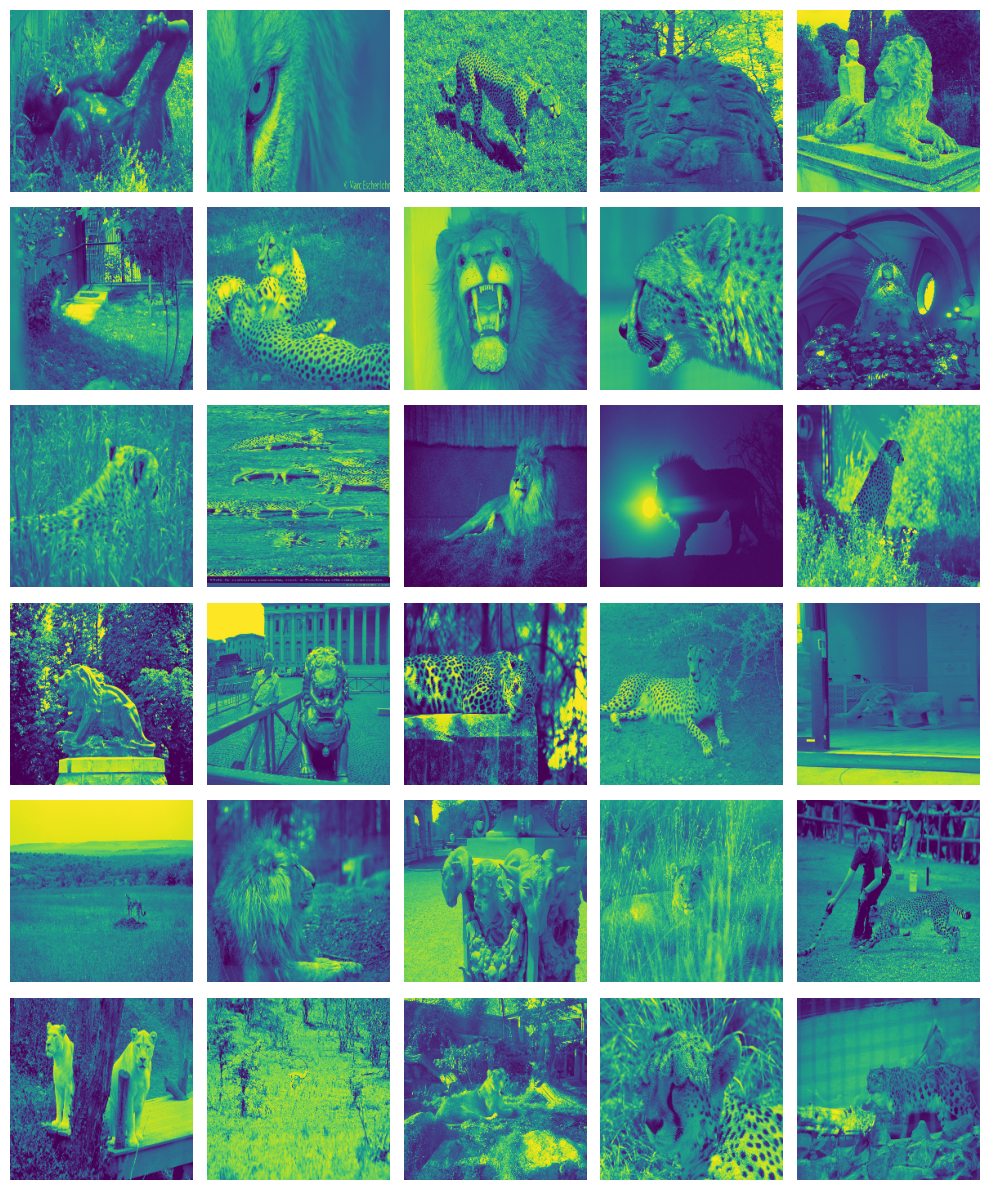

In [ ]:
image = next(iter(dataset[0]))[0]
image.shape
keras.visualization.plot_image_gallery(image, value_range=(0, 255))

In [ ]:
classifier = keras_hub.models.ImageClassifier.from_preset(
    "resnet_18_imagenet", num_classes = 1, activation = 'sigmoid')
classifier.summary()

Preprocessor: "res_net_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ res_net_image_converter (ResNetImageConverter)                │                   Image size: (224, 224) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "res_net_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)                    │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ res_net_backbone (ResNetBackbone)             │ (None, None, None, 512)            │          11,186,112 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ pooler (GlobalAveragePooling2D)               │ (None, 512)                        │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ output_dropout (Dropout)                      │ (None, 512)                        │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                           │ (None, 1)                          │                 513 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 11,186,625 (42.67 MB)

 Trainable params: 11,177,025 (42.64 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [ ]:
classifier.compile(loss = 'binary_crossentropy', optimizer = 'adamw', metrics = ['accuracy'])

In [ ]:
with tf.device('/GPU:0'):
  history = classifier.fit(dataset[0], validation_data =dataset[1], shuffle = True, epochs = 10)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 817ms/step - accuracy: 0.6304 - loss: 0.6630 - val_accuracy: 0.8250 - val_loss: 0.4884
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step - accuracy: 0.9576 - loss: 0.3428 - val_accuracy: 0.8500 - val_loss: 0.3869
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - accuracy: 0.9902 - loss: 0.1498 - val_accuracy: 0.8750 - val_loss: 0.3207
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 1.0000 - loss: 0.0748 - val_accuracy: 0.8500 - val_loss: 0.2802
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - accuracy: 1.0000 - loss: 0.0274 - val_accuracy: 0.8750 - val_loss: 0.2497
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - accuracy: 1.0000 - loss: 0.0125 - val_accuracy: 0.8750 - val_loss: 0.2543
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.8750 - val_loss: 0.2640
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.8750 - val_loss

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
import matplotlib.pyplot as plt

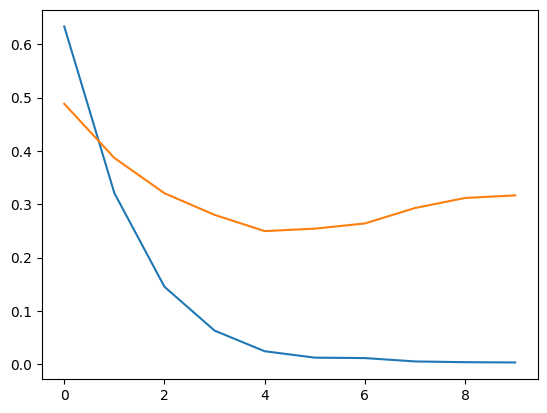

In [ ]:
plt.plot(history.history['loss'], label = 'train_loss')
plt.plot(history.history['val_loss'], label = 'val_loss')

In [ ]:
from keras.applications.imagenet_utils import decode_predictions

def get_imagenet_predictions(model, image_path):
    # Load and resize the image
    img = keras.utils.load_img(image_path, target_size=(224, 224))

    # Convert image to array
    img_arr = np.array(img)

    # Add batch dimension
    image_batch = np.expand_dims(img_arr, axis=0)

    # Predict probabilities
    probs = model.predict(image_batch)

    return dataset[0].class_names[np.int32(np.round(probs[0]))[0]]

In [ ]:
image_path = '/content/images/Lions/0017218b3f99aef7.jpg'
image_path = '/content/images/Cheetahs/0052cb267268c59e.jpg'
get_imagenet_predictions(classifier, image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


'Cheetahs'

## FER 2013

Load Data

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/probability/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import os
import shutil
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [ ]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
  0% 0.00/60.3M [00:00<?, ?B/s]
100% 60.3M/60.3M [00:00<00:00, 1.07GB/s]


In [ ]:
!unzip '/content/fer2013.zip'

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

In [ ]:
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Define the dataset directory
dataset_test = '/content/test'
dataset_train = '/content/train'

In [ ]:
# Create an ImageDataGenerator instance
train_datagen = ImageDataGenerator(
    width_shift_range = 0.1,        # Randomly shift the width of images by up to 10%
    height_shift_range = 0.1,       # Randomly shift the height of images by up to 10%
    horizontal_flip = True,         # Flip images horizontally at random
    rescale = 1./255,               # Rescale pixel values to be between 0 and 1
    shear_range=0.1,
    zoom_range=0.1,
    rotation_range=10,
    validation_split = 0.2          # Set aside 20% of the data for validation
)
train_datagen

In [ ]:
validation_datagen = ImageDataGenerator(
    rescale = 1./255,               # Rescale pixel values to be between 0 and 1
    validation_split = 0.2          # Set aside 20% of the data for validation
)
validation_datagen

In [ ]:
# Load training data
train_generator = train_datagen.flow_from_directory(
    dataset_train,
    target_size=(48, 48),  # Adjust based on your CNN input size
    batch_size=32,
    color_mode = 'grayscale',
    class_mode='categorical',  # Use 'sparse' for integer labels
    subset='training'
)
train_generator

Found 22968 images belonging to 7 classes.


In [ ]:
# Load validation data
val_generator = validation_datagen.flow_from_directory(
    dataset_test,
    target_size=(48, 48),
    batch_size=32,
    color_mode = 'grayscale',
    class_mode='categorical',
    subset='validation'
)
val_generator

Found 1432 images belonging to 7 classes.


In [ ]:
print("Class labels:", train_generator.class_indices)

Class labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


### Building a model

#### All layers: Trainable and Freeze

In [ ]:
import keras_hub

In [ ]:
model = keras_hub.models.VGGImageClassifier.from_preset(
    "vgg_16_imagenet",
    num_classes = 7
)

100%|██████████| 495/495 [00:00<00:00, 1.34MB/s]


100%|██████████| 3.04k/3.04k [00:00<00:00, 7.99MB/s]


100%|██████████| 528M/528M [00:10<00:00, 53.5MB/s]


100%|██████████| 56.2M/56.2M [00:01<00:00, 35.8MB/s]


In [ ]:
# --- Compile the model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Preprocessor: "vgg_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vgg_image_converter (VGGImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vgg_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)                      │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vgg_backbone (VGGBackbone)                    │ (None, None, None, 512)            │          14,714,688 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ head (Sequential)                             │ (None, 7)                          │         119,574,535 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 134,289,223 (512.27 MB)

 Trainable params: 134,289,223 (512.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.layers

[<InputLayer name=input_layer, built=True>,
 <VGGBackbone name=vgg_backbone, built=True>,
 <Sequential name=head, built=True>]

In [ ]:
# Make all layers trainable for fine-tuning
model.trainable = True

In [ ]:
# --- Compile the model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Preprocessor: "vgg_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vgg_image_converter (VGGImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vgg_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)                      │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vgg_backbone (VGGBackbone)                    │ (None, None, None, 512)            │          14,714,688 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ head (Sequential)                             │ (None, 7)                          │         119,574,535 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 134,289,223 (512.27 MB)

 Trainable params: 134,289,223 (512.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Make all layers Non trainable for fine-tuning
model.trainable = False

In [ ]:
# --- Compile the model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Preprocessor: "vgg_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vgg_image_converter (VGGImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vgg_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)                      │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vgg_backbone (VGGBackbone)                    │ (None, None, None, 512)            │          14,714,688 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ head (Sequential)                             │ (None, 7)                          │         119,574,535 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 134,289,223 (512.27 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 134,289,223 (512.27 MB)

#### Unfreeze Head

In [ ]:
model.head.layers

[<Conv2D name=fc1, built=True>,
 <Dropout name=output_dropout, built=True>,
 <Conv2D name=fc2, built=True>,
 <GlobalAveragePooling2D name=pooler, built=True>,
 <Dense name=predictions, built=True>]

In [ ]:
model = keras_hub.models.VGGImageClassifier.from_preset(
    "vgg_16_imagenet",
    num_classes = 7
)

In [ ]:
# --- Compile the model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
for layer in model.layers:
  print(layer)
  layer.trainable = False

<InputLayer name=input_layer_10, built=True>
<VGGBackbone name=vgg_backbone_5, built=True>
<Sequential name=head, built=True>


In [ ]:
model.summary()

Preprocessor: "vgg_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vgg_image_converter (VGGImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vgg_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)                   │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vgg_backbone_5 (VGGBackbone)                  │ (None, None, None, 512)            │          14,714,688 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ head (Sequential)                             │ (None, 7)                          │         119,574,535 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 134,289,223 (512.27 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 134,289,223 (512.27 MB)

In [ ]:
for layer in model.layers[-1:]:
  print(layer)
  layer.trainable = True

<Sequential name=head, built=True>


In [ ]:
# --- Compile the model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Preprocessor: "vgg_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vgg_image_converter (VGGImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vgg_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)                   │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vgg_backbone_5 (VGGBackbone)                  │ (None, None, None, 512)            │          14,714,688 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ head (Sequential)                             │ (None, 7)                          │         119,574,535 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 134,289,223 (512.27 MB)

 Trainable params: 119,574,535 (456.14 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

#### Unfreeze last two layers

In [ ]:
model = keras_hub.models.VGGImageClassifier.from_preset(
    "vgg_16_imagenet",
    num_classes = 7
)

In [ ]:
# --- Compile the model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Preprocessor: "vgg_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vgg_image_converter (VGGImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vgg_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_35 (InputLayer)                   │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vgg_backbone_17 (VGGBackbone)                 │ (None, None, None, 512)            │          14,714,688 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ head (Sequential)                             │ (None, 7)                          │         119,574,535 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 134,289,223 (512.27 MB)

 Trainable params: 134,289,223 (512.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
for layer in model.layers:
  print(layer)
  layer.trainable = False

<InputLayer name=input_layer_35, built=True>
<VGGBackbone name=vgg_backbone_17, built=True>
<Sequential name=head, built=True>


In [ ]:
# Alternatively, make specific layers trainable like this:
for layer in model.layers[-2:]:
  print(layer)
  layer.trainable = True

<VGGBackbone name=vgg_backbone_17, built=True>
<Sequential name=head, built=True>


In [ ]:
# --- Compile the model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Preprocessor: "vgg_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vgg_image_converter (VGGImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vgg_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)                   │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vgg_backbone_10 (VGGBackbone)                 │ (None, None, None, 512)            │          14,714,688 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ head (Sequential)                             │ (None, 7)                          │         119,574,535 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 134,289,223 (512.27 MB)

 Trainable params: 134,289,223 (512.27 MB)

 Non-trainable params: 0 (0.00 B)

#### Unfreeze last layer in head

In [ ]:
model = keras_hub.models.VGGImageClassifier.from_preset(
    "vgg_16_imagenet",
    num_classes = 7
)

In [ ]:
# --- Compile the model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Preprocessor: "vgg_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vgg_image_converter (VGGImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vgg_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_39 (InputLayer)                   │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vgg_backbone_19 (VGGBackbone)                 │ (None, None, None, 512)            │          14,714,688 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ head (Sequential)                             │ (None, 7)                          │         119,574,535 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 134,289,223 (512.27 MB)

 Trainable params: 134,289,223 (512.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.backbone.summary()

Model: "vgg_backbone_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_39 (InputLayer)     │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.backbone.trainable = False

In [ ]:
model.backbone.summary()

Model: "vgg_backbone_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_39 (InputLayer)     │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.head.summary()

Model: "head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc1 (Conv2D)                    │ (None, None, None,     │   102,764,544 │
│                                 │ 4096)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dropout (Dropout)        │ (None, None, None,     │             0 │
│                                 │ 4096)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Conv2D)                    │ (None, None, None,     │    16,781,312 │
│                                 │ 4096)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooler (GlobalAveragePooling2D) │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 7)              │        28,679 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,574,535 (456.14 MB)

 Trainable params: 119,574,535 (456.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
for layer in model.head.layers[:-1]:
  print(layer)
  layer.trainable = False

<Conv2D name=fc1, built=True>
<Dropout name=output_dropout, built=True>
<Conv2D name=fc2, built=True>
<GlobalAveragePooling2D name=pooler, built=True>


In [ ]:
# --- Compile the model ---
model.head.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.head.summary()

Model: "head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc1 (Conv2D)                    │ (None, None, None,     │   102,764,544 │
│                                 │ 4096)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dropout (Dropout)        │ (None, None, None,     │             0 │
│                                 │ 4096)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Conv2D)                    │ (None, None, None,     │    16,781,312 │
│                                 │ 4096)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooler (GlobalAveragePooling2D) │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 7)              │        28,679 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,574,535 (456.14 MB)

 Trainable params: 28,679 (112.03 KB)

 Non-trainable params: 119,545,856 (456.03 MB)

In [ ]:
model.summary()

Preprocessor: "vgg_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vgg_image_converter (VGGImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vgg_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_39 (InputLayer)                   │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vgg_backbone_19 (VGGBackbone)                 │ (None, None, None, 512)            │          14,714,688 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ head (Sequential)                             │ (None, 7)                          │         119,574,535 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 134,289,223 (512.27 MB)

 Trainable params: 28,679 (112.03 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

#### Unfreeze whole head and last layer in backbone

In [ ]:
model = keras_hub.models.VGGImageClassifier.from_preset(
    "vgg_16_imagenet",
    num_classes = 7
)

In [ ]:
# --- Compile the model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Preprocessor: "vgg_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vgg_image_converter (VGGImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vgg_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_41 (InputLayer)                   │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vgg_backbone_20 (VGGBackbone)                 │ (None, None, None, 512)            │          14,714,688 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ head (Sequential)                             │ (None, 7)                          │         119,574,535 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 134,289,223 (512.27 MB)

 Trainable params: 134,289,223 (512.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
for layer in model.backbone.layers[:-2]:
  layer.trainable = False

In [ ]:
model.summary()

Preprocessor: "vgg_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vgg_image_converter (VGGImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vgg_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_41 (InputLayer)                   │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vgg_backbone_20 (VGGBackbone)                 │ (None, None, None, 512)            │          14,714,688 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ head (Sequential)                             │ (None, 7)                          │         119,574,535 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 134,289,223 (512.27 MB)

 Trainable params: 121,934,343 (465.14 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

In [ ]:
from keras.callbacks import EarlyStopping, TensorBoard, ModelCheckpoint
import datetime

In [ ]:
# --- Define Callbacks ---
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Model checkpoint to save the best model
checkpoint = ModelCheckpoint(
    "emotions.h5",  # File name
    monitor='val_accuracy',  # Save the model with the best validation accuracy
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=1,  # Can be higher since early stopping prevents unnecessary training
    batch_size=32,
    verbose=1,
    callbacks=[tensorboard_callback, early_stopping_callback,checkpoint]  # Add callbacks here
)

ValueError: Can't convert non-rectangular Python sequence to Tensor.

In [ ]:
# --- Evaluate the model ---
eval_loss, eval_acc = classifier.evaluate(val_generator)
print(f"Validation Loss: {eval_loss:.4f}, Validation Accuracy: {eval_acc:.4f}")

In [ ]:
# --- Predict on new data ---
# Example: predict a batch from validation set
predictions = classifier.predict(val_generator)
predicted_classes = tf.argmax(predictions, axis=1)
print("Predicted classes:", predicted_classes.numpy())